#  Импорты и загрузка данных

In [325]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pubchempy as pcp
import time

In [326]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [327]:
train_df = pd.read_csv(r'D:\studies\hack\data\daimler_mixtures_train.csv')
prop_df = pd.read_csv(r'D:\studies\hack\data\daimler_component_properties.csv')
test_df = pd.read_csv(r'D:\studies\hack\data\daimler_mixtures_test.csv')

In [328]:
rename_map = {
    'scenario_id': 'scenario_id',
    'Компонент': 'component',
    'Наименование партии': 'batch',
    'Массовая доля, %': 'mass_share',
    'Температура испытания | ASTM D445 Daimler Oxidation Test (DOT), °C': 'temp',
    'Время испытания | - Daimler Oxidation Test (DOT), ч': 'time',
    'Delta Kin. Viscosity KV100 - relative | - Daimler Oxidation Test (DOT), %': 'target_visc',
    'Oxidation EOT | DIN 51453 Daimler Oxidation Test (DOT), A/cm': 'target_oxid',
    'Количество биотоплива | - Daimler Oxidation Test (DOT), % масс': 'biofuel',
    'Дозировка катализатора, категория': 'catalyst'
}
train_df = train_df.rename(columns=rename_map)
test_df = test_df.rename(columns=rename_map)

In [329]:
train_df

,scenario_id,component,batch,mass_share,temp,time,target_visc,target_oxid,biofuel,catalyst
0,train_1,Антиоксидант_5,32,70.832,160,168,25.4,98.04,0,1
1,train_1,Антиоксидант_6,13799.21,70.832,160,168,25.4,98.04,0,1
2,train_1,Антипенная_присадка_3,б/н,3.991,160,168,25.4,98.04,0,1
3,train_1,Базовое_масло_10,0285.21,60.034,160,168,25.4,98.04,0,1
4,train_1,Базовое_масло_17,без номера,84.281,160,168,25.4,98.04,0,1
...,...,...,...,...,...,...,...,...,...,...
2225,train_167,Базовое_масло_1,01595.25,43.229,160,168,-37.0,41.93,0,1
2226,train_167,Базовое_масло_5,01624.25,22.895,160,168,-37.0,41.93,0,1
2227,train_167,Детергент_1,01558.25,8.080,160,168,-37.0,41.93,0,1
2228,train_167,Загуститель_1,01609.25,2.675,160,168,-37.0,41.93,0,1


In [330]:
prop_df

,Компонент,Наименование партии,Наименование показателя,Единица измерения_по_партиям,Значение показателя
0,Детергент_4,0338.22,"Кинематическая вязкость, при 100°C, ASTM D445",мм²/с,16.68
1,Детергент_4,0338.22,"Массовая доля кальция, ASTM D6481",% масс,6.144
2,Детергент_4,0338.22,"Массовая доля цинка, ASTM D6481",% масс,0.0064
3,Детергент_4,0338.22,"Щелочное число, ASTM D2896",мг KOH/г,168
4,Противоизносная_присадка_8,0186.22,"Кинематическая вязкость, при 100°C, ASTM D445",мм²/с,13.74
...,...,...,...,...,...
2636,Базовое_масло_8,typical,"Содержание серы, мг/кг",NaN,<10
2637,Базовое_масло_4,typical,"Содержание серы, мг/кг",NaN,<10
2638,Базовое_масло_16,typical,Содержание ароматики,NaN,<3
2639,Базовое_масло_14,typical,Содержание ароматики,NaN,<3


In [331]:
test_df

,scenario_id,component,batch,mass_share,temp,time,biofuel,catalyst
0,test_1,Антиоксидант_4,01050.22,95.918,160,168,0,1
1,test_1,Базовое_масло_1,03197.24,43.340,160,168,0,1
2,test_1,Базовое_масло_1,03197.24,43.229,160,168,0,1
3,test_1,Базовое_масло_5,03159.24,22.895,160,168,0,1
4,test_1,Детергент_1,03052.24,8.080,160,168,0,1
...,...,...,...,...,...,...,...,...
519,test_40,Базовое_масло_5,02510.25,12.549,160,168,5,2
520,test_40,Депрессорная_присадка_1,0862.24,43.971,160,168,5,2
521,test_40,Детергент_1,01777.25,91.514,160,168,5,2
522,test_40,Загуститель_3,п. B118590651,94.025,160,168,5,2


In [332]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2230 entries, 0 to 2229
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   scenario_id  2230 non-null   object 
 1   component    2230 non-null   object 
 2   batch        2228 non-null   object 
 3   mass_share   2230 non-null   float64
 4   temp         2230 non-null   int64  
 5   time         2230 non-null   int64  
 6   target_visc  2230 non-null   float64
 7   target_oxid  2230 non-null   float64
 8   biofuel      2230 non-null   int64  
 9   catalyst     2230 non-null   int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 174.3+ KB


In [333]:
prop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2641 entries, 0 to 2640
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Компонент                     2641 non-null   object
 1   Наименование партии           2635 non-null   object
 2   Наименование показателя       2557 non-null   object
 3   Единица измерения_по_партиям  1835 non-null   object
 4   Значение показателя           2557 non-null   object
dtypes: object(5)
memory usage: 103.3+ KB


In [334]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524 entries, 0 to 523
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   scenario_id  524 non-null    object 
 1   component    524 non-null    object 
 2   batch        524 non-null    object 
 3   mass_share   524 non-null    float64
 4   temp         524 non-null    int64  
 5   time         524 non-null    int64  
 6   biofuel      524 non-null    int64  
 7   catalyst     524 non-null    int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 32.9+ KB


In [335]:
print(f"Сценариев в train: {train_df['scenario_id'].nunique()}")
print(f"Сценариев в test: {test_df['scenario_id'].nunique()}")

Сценариев в train: 167
Сценариев в test: 40


# Анализ целевых показателей

In [336]:
scenarios_df = train_df.groupby('scenario_id').first().reset_index()

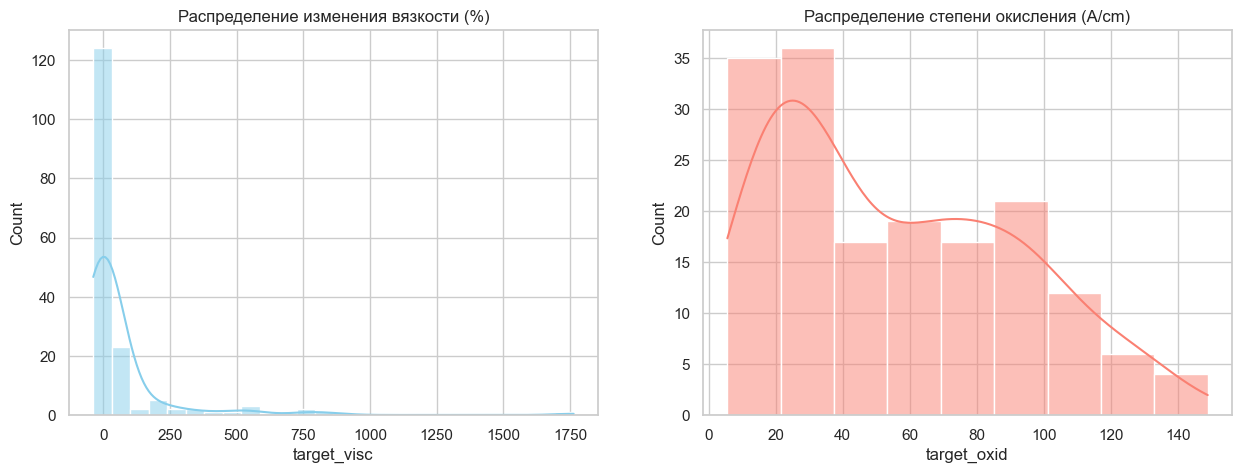

In [337]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(scenarios_df['target_visc'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Распределение изменения вязкости (%)')
sns.histplot(scenarios_df['target_oxid'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Распределение степени окисления (A/cm)')
plt.show()

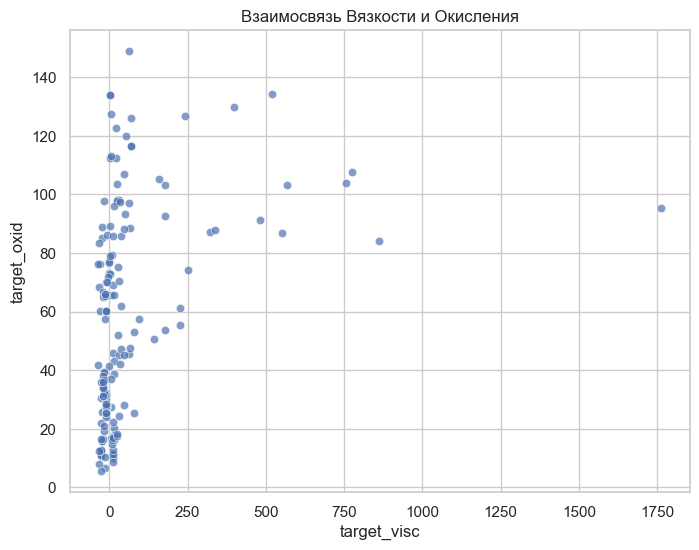

In [338]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=scenarios_df, x='target_visc', y='target_oxid', alpha=0.7)
plt.title('Взаимосвязь Вязкости и Окисления')
plt.show()

In [339]:
print("Сценарии с максимальным изменением вязкости:")
display(scenarios_df.sort_values('target_visc', ascending=False)[['scenario_id', 'target_visc', 'temp', 'time', 'catalyst']].head())

Сценарии с максимальным изменением вязкости:


,scenario_id,target_visc,temp,time,catalyst
9,train_107,1763.34,150,216,1
8,train_106,861.54,150,168,1
13,train_110,775.51,150,216,1
21,train_118,754.93,150,216,1
148,train_82,566.53,150,216,1


Распределение имеет экстремальный тяжелый правый хвост со скачками до 1763%, в то время как основная масса значений сконцентрирована около нуля. Модели потребуется робастная функция потерь, чтобы эти выбросы не сломали градиенты при обучении.

Распределение степени окисления асимметрично. Имеет четко выраженный основной пик в зоне низких значений (20–40 A/cm) и широкое плато в зоне сильной деградации (80–110 A/cm). Это подтверждает наличие разных физико-химических режимов течения теста.

На графике рассеяния видно плотное вертикальное скопление точек около нулевого изменения вязкости. Это означает, что масло может сильно окисляться (значения target_oxid достигают 120–140 A/cm), но при этом сохранять свою текучесть (target_visc около 0%).
Рост вязкости (>250%) начинается только тогда, когда окисление уже превысило порог примерно в 80 A/cm.

Вывод: высокое окисление - это необходимое, но не достаточное условие для потери вязкости

# Анализ состава (топ компонентов и доли)

C:\Users\Анастасия\AppData\Local\Temp\ipykernel_22412\3921678621.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_components.values, y=top_components.index, palette='viridis')


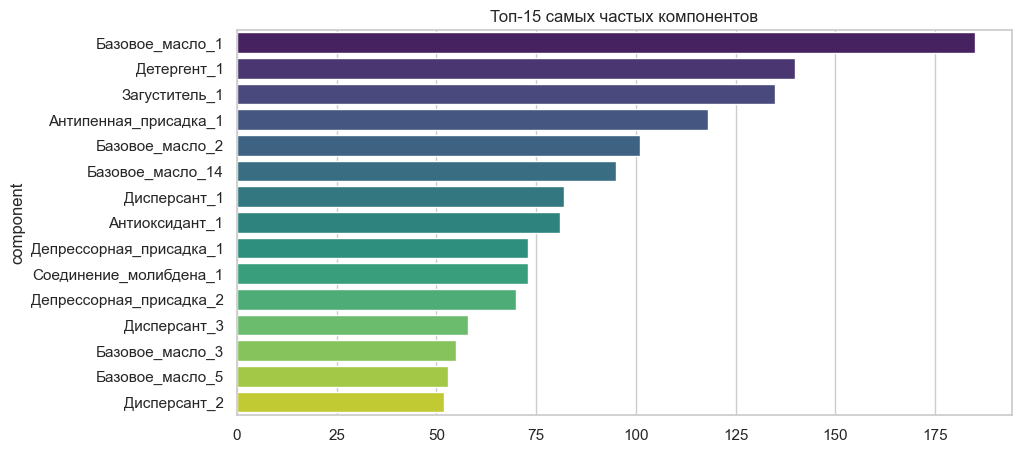

In [340]:
top_components = train_df['component'].value_counts().head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_components.values, y=top_components.index, palette='viridis')
plt.title('Топ-15 самых частых компонентов')
plt.show()

In [341]:
extreme_scenarios = scenarios_df[scenarios_df['target_visc'] > 500]['scenario_id']
extreme_components = train_df[train_df['scenario_id'].isin(extreme_scenarios)]['component'].unique()

print(f"Количество компонентов в экстремальных сценариях (>500% вязкости): {len(extreme_components)}")

Количество компонентов в экстремальных сценариях (>500% вязкости): 20


На графике четко видна стабильная база, вокруг которой строятся эксперименты. Почти во всех смесях присутствуют Базовое_масло_1, Детергент_1, Загуститель_1 и Антипенная_присадка_1.

В экстремальных сценариях встречается аж 20 различных компонентов.

Разрушение масла - это не вина какой-то одной конкретной ядовитой присадки. Это результат химической несовместимости целого коктейля веществ при стрессовых условиях

# Анализ рецептур (дубликаты и аномалии)

In [342]:
mass_sums = train_df.groupby('scenario_id')['mass_share'].sum()
mass_sums.describe()

count    167.000000
mean     587.824563
std      145.346486
min      247.229000
25%      514.145000
50%      589.432000
75%      691.561000
max      956.364000
Name: mass_share, dtype: float64

In [343]:
recipe_fingerprint = train_df.sort_values(['scenario_id', 'component']).groupby('scenario_id').apply(
    lambda x: "|".join([f"{c}:{m}" for c, m in zip(x['component'], x['mass_share'])]),
    include_groups=False
)
duplicated_recipes = recipe_fingerprint[recipe_fingerprint.duplicated(keep=False)].index
print(f"Найдено идентичных химических составов (дубликатов): {len(duplicated_recipes)}")

Найдено идентичных химических составов (дубликатов): 47


In [344]:
df_fingerprints = recipe_fingerprint.reset_index()
df_fingerprints.columns = ['scenario_id', 'fingerprint']

duplicates_detailed = df_fingerprints.merge(
    scenarios_df[['scenario_id', 'temp', 'time', 'biofuel', 'catalyst', 'target_visc', 'target_oxid']], 
    on='scenario_id'
)

duplicates_detailed = duplicates_detailed[duplicates_detailed.duplicated(subset=['fingerprint'], keep=False)]

duplicates_detailed = duplicates_detailed.sort_values(by=['fingerprint', 'temp', 'time'])

In [345]:
print(f"Анализ сценариев с идентичным составом")
display(duplicates_detailed[['scenario_id', 'temp', 'time', 'biofuel', 'catalyst', 'target_visc', 'target_oxid', 'fingerprint']].head(20))

Анализ сценариев с идентичным составом


,scenario_id,temp,time,biofuel,catalyst,target_visc,target_oxid,fingerprint
60,train_153,150,168,7,2,10.77,45.93,Антиоксидант_1:0.422|Антиоксидант_2:23.42|Анти...
61,train_154,150,216,7,2,29.31,75.09,Антиоксидант_1:0.422|Антиоксидант_2:23.42|Анти...
59,train_152,160,168,5,1,16.58,38.80,Антиоксидант_1:0.422|Антиоксидант_2:23.42|Анти...
62,train_155,160,168,5,2,36.30,61.83,Антиоксидант_1:0.422|Антиоксидант_2:23.42|Анти...
63,train_156,150,168,7,1,32.46,45.20,Антиоксидант_1:0.422|Антиоксидант_2:23.42|Анти...
64,train_157,150,216,7,1,79.90,52.89,Антиоксидант_1:0.422|Антиоксидант_2:23.42|Анти...
65,train_158,150,168,7,1,36.63,47.24,Антиоксидант_1:0.422|Антиоксидант_2:23.42|Анти...
66,train_159,150,216,7,1,95.96,57.58,Антиоксидант_1:0.422|Антиоксидант_2:23.42|Анти...
68,train_160,160,168,5,1,48.52,45.28,Антиоксидант_1:0.422|Антиоксидант_2:23.42|Анти...
132,train_68,160,168,0,1,-27.19,12.61,Антиоксидант_1:0.422|Антиоксидант_9:56.357|Баз...


In [346]:
stats_diff = duplicates_detailed.groupby('fingerprint').agg({
    'temp': 'nunique',
    'time': 'nunique',
    'target_visc': ['min', 'max', 'std']
})

In [347]:
print("Статистика вариативности внутри групп-дублей")
display(stats_diff.head())

Статистика вариативности внутри групп-дублей


temp    time  \
                                                   nunique nunique   
fingerprint                                                          
Антиоксидант_1:0.422|Антиоксидант_2:23.42|Антип...       2       2   
Антиоксидант_1:0.422|Антиоксидант_2:23.42|Антип...       1       2   
Антиоксидант_1:0.422|Антиоксидант_2:23.42|Антип...       2       2   
Антиоксидант_1:0.422|Антиоксидант_9:56.357|Базо...       1       1   
Антиоксидант_1:17.074|Антиоксидант_3:26.931|Ант...       1       2   

                                                   target_visc          \
                                                           min     max   
fingerprint                                                              
Антиоксидант_1:0.422|Антиоксидант_2:23.42|Антип...       10.77   36.30   
Антиоксидант_1:0.422|Антиоксидант_2:23.42|Антип...       32.46   79.90   
Антиоксидант_1:0.422|Антиоксидант_2:23.42|Антип...       36.63   95.96   
Антиоксидант_1:0.422|Антиоксидант_9:56.357|Базо...      -27.19  -26.61   
Антиоксидант_1:17.074|Антиоксидант_3:26.931|Ант...      157.99  241.52   

                                                               
                                                          std  
fingerprint                                                    
Антиоксидант_1:0.422|Антиоксидант_2:23.42|Антип...  11.651395  
Антиоксидант_1:0.422|Антиоксидант_2:23.42|Антип...  33.545146  
Антиоксидант_1:0.422|Антиоксидант_2:23.42|Антип...  31.389952  
Антиоксидант_1:0.422|Антиоксидант_9:56.357|Базо...   0.410122  
Антиоксидант_1:17.074|Антиоксидант_3:26.931|Ант...  59.064629

In [348]:
target_ids = ['train_106', 'train_117', 'train_107', 'train_118']

comp_comparison = train_df[train_df['scenario_id'].isin(target_ids)].pivot_table(
    index=['component', 'batch'], 
    columns='scenario_id', 
    values='mass_share'
).sort_index()

In [349]:
print("Покомпонентное сравнение масс")
display(comp_comparison)

Покомпонентное сравнение масс


,scenario_id,train_106,train_107,train_117,train_118
component,batch,,,,
Антиоксидант_2,01623.24,38.014,38.014,38.014,38.014
Антипенная_присадка_1,Р-10 3% р-р от 16.04,3.991,3.991,3.991,3.991
Базовое_масло_1,0318.25,38.413,38.413,38.413,38.413
Базовое_масло_14,Р-10 от 13.05.2024,84.281,84.281,84.281,84.281
Базовое_масло_4,01209.25 для SL,18.485,18.485,18.485,18.485
Базовое_масло_8,01208.25 для SL,52.846,52.846,52.846,52.846
Депрессорная_присадка_2,01190.25 для SL,43.971,43.971,43.971,43.971
Детергент_1,0432.25,31.092,31.092,31.092,31.092
Дисперсант_1,01191.25 для SL,74.243,74.243,NaN,NaN


In [350]:
print("Суммарная масса сценариев ===")
display(train_df[train_df['scenario_id'].isin(target_ids)].groupby('scenario_id')['mass_share'].sum())

Суммарная масса сценариев ===


scenario_id
train_106    514.145
train_107    514.145
train_117    514.145
train_118    514.145
Name: mass_share, dtype: float64

In [351]:
print("Сравнение результатов")
display(scenarios_df[scenarios_df['scenario_id'].isin(target_ids)][['scenario_id', 'target_visc', 'target_oxid']])

Сравнение результатов


,scenario_id,target_visc,target_oxid
8,train_106,861.54,84.25
9,train_107,1763.34,95.47
20,train_117,482.89,91.23
21,train_118,754.93,103.98


In [352]:
internal_doubles = train_df.groupby(['scenario_id', 'component']).size().reset_index(name='count')
print(f"Сценариев с задвоенными компонентами (разные партии одного вещества): {internal_doubles[internal_doubles['count'] > 1]['scenario_id'].nunique()}")

Сценариев с задвоенными компонентами (разные партии одного вещества): 90


In [353]:
def extract_numbers(text):
    nums = re.findall(r'\d+[.,]\d+|\d+', str(text))
    return "|".join(nums) if nums else None

train_df['batch_hidden_nums'] = train_df['batch'].apply(extract_numbers)
hidden_data = train_df[train_df['batch_hidden_nums'].notna()][['batch', 'batch_hidden_nums']].drop_duplicates()
print("\nСкрытые концентрации в названиях партий (примеры):")
display(hidden_data.head(5))


Скрытые концентрации в названиях партий (примеры):

,batch,batch_hidden_nums
0,32,32
1,13799.21,13799.21
3,0285.21,0285.21
5,0204.22,0204.22
6,0186.21,0186.21


#  Матрица условий и Температурный парадокс

In [354]:
conditions_pivot = scenarios_df.pivot_table(index='temp', columns='time', values='scenario_id', aggfunc='count', fill_value=0)
print("Температура vs Время")
display(conditions_pivot)

Температура vs Время


time,168,216
temp,,
150,13,15
154,0,2
160,137,0


In [355]:
bio_temp_check = scenarios_df.groupby(['temp', 'biofuel']).size().unstack(fill_value=0)
print("Распределение Биотоплива по Температурам")
display(bio_temp_check)

Распределение Биотоплива по Температурам


biofuel,0,5,7
temp,,,
150,1,0,27
154,0,0,2
160,115,14,8


In [356]:
gold_nugget = scenarios_df[(scenarios_df['temp'] == 150) & (scenarios_df['biofuel'] == 0)]
print("Контрольный сценарий (150°C, 0% biofuel)")
display(gold_nugget[['scenario_id', 'temp', 'time', 'biofuel', 'target_visc']])

Контрольный сценарий (150°C, 0% biofuel)


,scenario_id,temp,time,biofuel,target_visc
35,train_130,150,216,0,15.22


Температура 150°C кажется разрушительной только потому, что там всегда добавлено 7% биотоплива. Единственный сценарий при 150°C без топлива показал стабильную вязкость (15%). Биотопливо - приоритетный катализатор старения для модели.

In [357]:
train_comps = set(train_df['component'].unique())
test_comps = set(test_df['component'].unique())
new_comps = test_comps - train_comps

print(f"Новых компонентов в тесте, которых НЕТ в трейне: {len(new_comps)}")

Новых компонентов в тесте, которых НЕТ в трейне: 8


In [358]:
if new_comps:
    print(list(new_comps))

train_grid = train_df.groupby(['temp', 'time']).size().reset_index(name='train_count')
test_grid = test_df.groupby(['temp', 'time']).size().reset_index(name='test_count')
grid_compare = train_grid.merge(test_grid, on=['temp', 'time'], how='outer').fillna(0)
print("Сетка условий (Train vs Test)")
display(grid_compare)

['Соединение_молибдена_4', 'Детергент_15', 'Базовое_масло_15', 'Соединение_молибдена_3', 'Противоизносная_присадка_9', 'Противоизносная_присадка_24', 'Противоизносная_присадка_12', 'Базовое_масло_12']
Сетка условий (Train vs Test)


,temp,time,train_count,test_count
0,150,168,174,56
1,150,216,199,83
2,154,216,30,13
3,160,168,1827,372


# Анализ свойств (единицы измерения и методы)

In [359]:
def extract_method(text):
    match = re.search(r'(ASTM D\d+|DIN \d+|ГОСТ \d+)', str(text))
    return match.group(1) if match else "No Method"

In [360]:
def clean_param_name(text):
    return re.sub(r',? (ASTM D\d+|DIN \d+|ГОСТ \d+).*', '', str(text)).strip()

In [361]:
prop_df['method'] = prop_df['Наименование показателя'].apply(extract_method)
prop_df['param_base_name'] = prop_df['Наименование показателя'].apply(clean_param_name)

In [362]:
unit_check = prop_df.groupby('Наименование показателя')['Единица измерения_по_партиям'].nunique()
multi_units = unit_check[unit_check > 1]
print("Свойства с РАЗНЫМИ единицами измерения:")
display(prop_df[prop_df['Наименование показателя'].isin(multi_units.index)][['Наименование показателя', 'Единица измерения_по_партиям']].drop_duplicates())

Свойства с РАЗНЫМИ единицами измерения:


,Наименование показателя,Единица измерения_по_партиям
20,"Индекс вязкости, ГОСТ 25371",–
21,"Испаряемость по NOACK, ASTM D5800",%
363,"Плотность при 15°С, ASTM D4052",кг/м³
2006,"Плотность при 15°С, ASTM D4052",г/см³
2584,"Индекс вязкости, ГОСТ 25371",-
2595,"Испаряемость по NOACK, ASTM D5800",% масс


In [363]:
tbn_check = prop_df[prop_df['param_base_name'] == 'Щелочное число'].copy()
tbn_check['numeric_val'] = pd.to_numeric(tbn_check['Значение показателя'].str.replace(',','.').str.extract(r'(\d+\.?\d*)')[0], errors='coerce')
print("Разброс значений Щелочного числа по методам:")
display(tbn_check.dropna(subset=['numeric_val']).groupby('method')['numeric_val'].agg(['mean', 'count']))

Разброс значений Щелочного числа по методам:


,mean,count
method,,
ASTM D2896,154.519211,76
ГОСТ 11362,103.393500,20


Плотность измеряется в г/см^3 и кг/м^3 (ошибка в 1000 раз, нужна нормализация). Щелочное число измерено разными методами (ASTM и ГОСТ) с разницей в средних значениях на 50%. Их нужно подавать как разные фичи.

In [364]:
def clean_chemistry_values(val):
    val = str(val).strip().replace(',', '.').replace('<', '').replace('>', '')
    try:
        return float(val)
    except:
        return val

In [365]:
prop_df['cleaned_value'] = prop_df['Значение показателя'].apply(clean_chemistry_values)

df_typ = prop_df[prop_df['Наименование партии'] == 'typical']
df_act = prop_df[prop_df['Наименование партии'] != 'typical']

pivot_typ = df_typ.pivot_table(index='Компонент', columns='Наименование показателя', values='cleaned_value', aggfunc='first')
pivot_act = df_act.pivot_table(index=['Компонент', 'Наименование партии'], columns='Наименование показателя', values='cleaned_value', aggfunc='first').reset_index()

In [366]:
final_features_df = pivot_act.copy()
for col in pivot_typ.columns:
    if col in final_features_df.columns:
        filler = final_features_df['Компонент'].map(pivot_typ[col])
        final_features_df[col] = final_features_df[col].fillna(filler)
    else:
        final_features_df[col] = final_features_df['Компонент'].map(pivot_typ[col])

print(f"Широкая витрина свойств готова. Размер: {final_features_df.shape}")

Широкая витрина свойств готова. Размер: (221, 96)


C:\Users\Анастасия\AppData\Local\Temp\ipykernel_22412\1157236325.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_features_df[col] = final_features_df[col].fillna(filler)
C:\Users\Анастасия\AppData\Local\Temp\ipykernel_22412\1157236325.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_features_df[col] = final_features_df[col].fillna(filler)
C:\Users\Анастасия\AppData\Local\Temp\ipykernel_22412\1157236325.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call

In [367]:
numeric_props = final_features_df.select_dtypes(include=[np.number])
corr_matrix = numeric_props.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print(f"Найдено сильно коррелирующих дублей (>0.95): {len(to_drop)}")

Найдено сильно коррелирующих дублей (>0.95): 3


# Генерация SMILES Patching

In [368]:
# Словарь ручных "заглушек" для сложных полимеров и смесей по CAS
manual_chemical_db = {
    "125643-61-0": "CCC(CC)COC(=O)CCC1=CC(=C(C(=C1)C(C)(C)C)O)C(C)(C)C", 
    "68411-46-1": "CC(C)(C)CC(C)(C)C1=CC=C(C=C1)NC2=CC=C(C=C2)C(C)(C)CC(C)(C)C", 
    "84605-20-9": "CCCC(CC)COP(=S)([O-])OCC(CC)CCCC.[Zn+2]", 
    "134758-95-5": "CCCCCCCCCCCC1CC(=O)N(C1=O)CCN", 
    "36878-20-3": "CCCCCCCCCNC1=CC=C(C=C1)C2=CC=C(C=C2)N", 
}

class_structures = {
    'Антиоксидант': 'CC(C)(C)C1=CC(=CC(=C1O)C(C)(C)C)CCC(=O)OC',
    'Антипенная': 'C[Si](C)(C)O[Si](C)(C)O[Si](C)(C)C',           
    'Депрессорная': 'CC(=C)C(=O)OCCCCCCCCCCCC',                 
    'Дисперсант': 'CCCCCCCCCCCC1CC(=O)N(C1=O)CCN',              
    'Загуститель': 'CCCCCCCCCCCCCCCCCCCC',                       
    'Противоизносная': 'CC(C)COP(=S)([O-])OCC(C)C.[Zn+2]',       
    'Детергент': 'CCCCCCCCCCCC1=CC=C(S(=O)(=O)O[Ca])C=C1',      
    'Соединение_молибдена': 'CCCCCCCCOP(=S)(S)S[Mo](=S)S'       
}

In [369]:
def is_smiles(val):
    s = str(val)
    return len(s) > 15 and 'C' in s and ('(' in s or '=' in s)

In [370]:
smiles_dict = prop_df[prop_df['Значение показателя'].apply(is_smiles)].groupby('Компонент')['Значение показателя'].first().to_dict()

In [371]:
cas_data = prop_df[prop_df['Наименование показателя'].str.contains('CAS', na=False, case=False)].copy()
cas_data['cas_cleaned'] = cas_data['Значение показателя'].apply(lambda x: re.search(r'\d{2,7}-\d{2}-\d', str(x)).group(0) if re.search(r'\d{2,7}-\d{2}-\d', str(x)) else None)
cas_dict = cas_data.dropna(subset=['cas_cleaned']).groupby('Компонент')['cas_cleaned'].first().to_dict()

In [372]:
for comp, cas in cas_dict.items():
    if comp not in smiles_dict and cas in manual_chemical_db:
        smiles_dict[comp] = manual_chemical_db[cas]

In [373]:
all_components = pd.concat([train_df['component'], test_df['component']]).unique()
final_rows =[]

for comp in all_components:
    s_val = smiles_dict.get(comp)
    status = "Found"
    
    if s_val is None:
        comp_type = str(comp).split('_')[0]
        if 'Базовое_масло' in str(comp):
            s_val = "CCCCCCCCCCCCCCCCCCCC"
            status = "Representative"
        elif 'молибдена' in str(comp):
            s_val = class_structures['Соединение_молибдена']
            status = "Patched_by_Class"
        else:
            s_val = class_structures.get(comp_type, "CCCCCCCCCCCCCCCCCCCC")
            status = "Patched_by_Class"
            
    final_rows.append({'component': comp, 'smiles': s_val, 'status': status})

In [374]:
final_chem_map = pd.DataFrame(final_rows)
print(f"ИТОГОВАЯ КАРТА ХИМИИ")
print(final_chem_map['status'].value_counts())

ИТОГОВАЯ КАРТА ХИМИИ
status
Patched_by_Class    48
Found               47
Representative      17
Name: count, dtype: int64


In [375]:
properties_with_smiles = prop_df.merge(
    final_chem_map[['component', 'smiles']], 
    left_on='Компонент', 
    right_on='component', 
    how='left'
)

In [376]:
if 'component' in properties_with_smiles.columns:
    properties_with_smiles = properties_with_smiles.drop(columns=['component'])

In [377]:
properties_with_smiles.shape

(2641, 9)

In [378]:
properties_with_smiles.head(10)

,Компонент,Наименование партии,Наименование показателя,Единица измерения_по_партиям,Значение показателя,method,param_base_name,cleaned_value,smiles
0,Детергент_4,0338.22,"Кинематическая вязкость, при 100°C, ASTM D445",мм²/с,16.68,ASTM D445,"Кинематическая вязкость, при 100°C",16.68,O=C(O[Ca]OC(C1=C(O)C=C(CCCCCCCCCCCCCCCCC)C=C1)...
1,Детергент_4,0338.22,"Массовая доля кальция, ASTM D6481",% масс,6.144,ASTM D6481,Массовая доля кальция,6.144,O=C(O[Ca]OC(C1=C(O)C=C(CCCCCCCCCCCCCCCCC)C=C1)...
2,Детергент_4,0338.22,"Массовая доля цинка, ASTM D6481",% масс,0.0064,ASTM D6481,Массовая доля цинка,0.0064,O=C(O[Ca]OC(C1=C(O)C=C(CCCCCCCCCCCCCCCCC)C=C1)...
3,Детергент_4,0338.22,"Щелочное число, ASTM D2896",мг KOH/г,168,ASTM D2896,Щелочное число,168.0,O=C(O[Ca]OC(C1=C(O)C=C(CCCCCCCCCCCCCCCCC)C=C1)...
4,Противоизносная_присадка_8,0186.22,"Кинематическая вязкость, при 100°C, ASTM D445",мм²/с,13.74,ASTM D445,"Кинематическая вязкость, при 100°C",13.74,CC(C)COP(=S)([O-])OCC(C)C.[Zn+2]
5,Противоизносная_присадка_8,0186.22,"Массовая доля кальция, ASTM D6481",% масс,0.001,ASTM D6481,Массовая доля кальция,0.001,CC(C)COP(=S)([O-])OCC(C)C.[Zn+2]
6,Противоизносная_присадка_8,0186.22,"Массовая доля фосфора, ASTM D6481",% масс,8.049,ASTM D6481,Массовая доля фосфора,8.049,CC(C)COP(=S)([O-])OCC(C)C.[Zn+2]
7,Противоизносная_присадка_8,0186.22,"Массовая доля цинка, ASTM D6481",% масс,9.095,ASTM D6481,Массовая доля цинка,9.095,CC(C)COP(=S)([O-])OCC(C)C.[Zn+2]
8,Противоизносная_присадка_8,0186.22,"Щелочное число, ASTM D2896",мг KOH/г,17.8,ASTM D2896,Щелочное число,17.8,CC(C)COP(=S)([O-])OCC(C)C.[Zn+2]
9,Депрессорная_присадка_3,0246.22,"Кинематическая вязкость, при 40°C, ASTM D445",мм²/с,846.19,ASTM D445,"Кинематическая вязкость, при 40°C",846.19,CC(=C)C(=O)OCCCCCCCCCCCC


In [379]:
properties_with_smiles.to_csv('properties_with_smiles.csv', index=False, encoding='utf-8-sig')